In [1]:
import numpy as np
from scipy.linalg import solve_banded
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# Phase 1 BS functions (self-contained)
def bs_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    if T <= 0:
        return max(S-K, 0) if option_type=="call" else max(K-S, 0)
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == "call":
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

print("Imports OK ✓")

Imports OK ✓


In [2]:
def build_fd_grid(K, T, sigma, S_max_factor=4, I=200, N=200):
    """
    Build the finite difference grid and return grid parameters.

    Parameters
    ----------
    I : int — number of S steps
    N : int — number of time steps

    Returns
    -------
    dict of grid parameters
    """
    S_max = S_max_factor * K
    dS    = S_max / I
    dt    = T / N

    S_vec = np.linspace(0, S_max, I + 1)   # stock price nodes
    t_vec = np.linspace(0, T, N + 1)       # time nodes

    # Courant number — key stability parameter for explicit scheme
    # Explicit is stable only if dt ≤ dS² / (σ²·S_max²)  roughly
    courant = sigma**2 * S_max**2 * dt / dS**2
    print(f"Grid: I={I}, N={N}, dS={dS:.3f}, dt={dt:.5f}")
    print(f"Courant number: {courant:.3f}  "
          f"({'⚠ may be unstable for explicit' if courant > 0.5 else '✓ stable'})")

    return dict(S_max=S_max, dS=dS, dt=dt, S_vec=S_vec, I=I, N=N)


grid = build_fd_grid(K=100, T=1.0, sigma=0.20, I=200, N=200)

Grid: I=200, N=200, dS=2.000, dt=0.00500
Courant number: 8.000  (⚠ may be unstable for explicit)


In [4]:
def fd_explicit(S, K, T, r, sigma, q=0.0, option_type="call", I=200, N=200):
    """
    Price a European option using the explicit finite difference scheme.
    WARNING: may be unstable if dt is too large relative to dS.
    """
    S_max = 4 * K
    dS    = S_max / I
    dt    = T / N

    S_vec = np.arange(0, I + 1) * dS          # stock price at each node
    i_arr = np.arange(0, I + 1, dtype=float)  # node indices

    # ── Terminal condition (payoff at expiry) ──
    if option_type == "call":
        V = np.maximum(S_vec - K, 0.0)
    else:
        V = np.maximum(K - S_vec, 0.0)

    # ── Coefficients (interior nodes only: 1..I-1) ──
    i_int = i_arr[1:I]                           # interior indices
    sig2i2 = sigma**2 * i_int**2
    a = 0.5 * dt * (sig2i2 - (r - q) * i_int)
    b = 1.0 - dt * (sig2i2 + r)
    c = 0.5 * dt * (sig2i2 + (r - q) * i_int)

    # ── Backward time stepping ──
    for n in range(N - 1, -1, -1):
        tau = (N - n) * dt                        # time remaining

        # Update interior nodes
        V_new          = np.zeros(I + 1)
        V_new[1:I]     = a * V[0:I-1] + b * V[1:I] + c * V[2:I+1]

        # Boundary conditions
        if option_type == "call":
            V_new[0]   = 0.0
            V_new[I]   = S_max * np.exp(-q * tau) - K * np.exp(-r * tau)
        else:
            V_new[0]   = K * np.exp(-r * tau)
            V_new[I]   = 0.0

        V = V_new

    # Interpolate to get price at exact spot S
    idx   = S / dS
    i_low = int(idx)
    i_low = min(i_low, I - 1)
    w     = idx - i_low                          # interpolation weight
    return (1 - w) * V[i_low] + w * V[i_low + 1]


# Test
params = dict(S=100, K=100, T=1.0, r=0.05, sigma=0.20, q=0.0)
bs_c  = bs_price(**params, option_type="call")
# Explicit needs N >> I to satisfy the stability condition:
# dt < dS² / (σ²·S_max²)  →  N > I²·σ²·(S_max/K)²
# With I=200, σ=0.20, S_max=4K: N > 200²·0.04·16 = 25,600
# We use N=30,000 to be safe. Explicit is slow — this is why nobody uses it.
exp_c = fd_explicit(**params, option_type="call", I=200, N=30_000)
print(f"\nBS call       : {bs_c:.4f}")
print(f"Explicit (FD) : {exp_c:.4f}")
print(f"Error         : {abs(exp_c - bs_c):.5f}")


BS call       : 10.4506
Explicit (FD) : 10.4407
Error         : 0.00986


In [5]:
def fd_implicit(S, K, T, r, sigma, q=0.0, option_type="call",
                exercise="european", I=200, N=200):
    """
    Price European or American option using implicit finite differences.
    Unconditionally stable for any dt.
    American options handled via PSOR (see Cell 6).
    """
    S_max = 4 * K
    dS    = S_max / I
    dt    = T / N
    S_vec = np.arange(0, I + 1) * dS
    i_arr = np.arange(1, I, dtype=float)         # interior indices

    # ── Terminal condition ──
    if option_type == "call":
        V = np.maximum(S_vec - K, 0.0)
    else:
        V = np.maximum(K - S_vec, 0.0)

    # ── Coefficients (constant for uniform grid) ──
    sig2i2 = sigma**2 * i_arr**2
    a_vec  = -0.5 * dt * (sig2i2 - (r - q) * i_arr)
    b_vec  =  1.0 + dt * (sig2i2 + r)
    c_vec  = -0.5 * dt * (sig2i2 + (r - q) * i_arr)

    # Pack into banded matrix format for solve_banded
    # ab[0] = superdiagonal (c), ab[1] = diagonal (b), ab[2] = subdiagonal (a)
    n_int = I - 1
    ab    = np.zeros((3, n_int))
    ab[0, 1:]  = c_vec[:-1]    # superdiagonal
    ab[1, :]   = b_vec          # diagonal
    ab[2, :-1] = a_vec[1:]      # subdiagonal

    # ── Backward time stepping ──
    for n in range(N - 1, -1, -1):
        tau = (N - n) * dt

        # RHS = interior values at n+1
        rhs = V[1:I].copy()

        # Apply boundary conditions into RHS
        if option_type == "call":
            bc_lo = 0.0
            bc_hi = S_max * np.exp(-q * tau) - K * np.exp(-r * tau)
        else:
            bc_lo = K * np.exp(-r * tau)
            bc_hi = 0.0

        rhs[0]  -= a_vec[0]  * bc_lo
        rhs[-1] -= c_vec[-1] * bc_hi

        # Solve tridiagonal system
        V_int = solve_banded((1, 1), ab, rhs)

        # Reconstruct full V with boundaries
        V = np.concatenate([[bc_lo], V_int, [bc_hi]])

        # American early exercise (PSOR handled in Cell 6)
        if exercise == "american":
            intrinsic = (np.maximum(S_vec - K, 0) if option_type == "call"
                         else np.maximum(K - S_vec, 0))
            V = np.maximum(V, intrinsic)

    # Interpolate to exact spot S
    idx   = S / dS
    i_low = min(int(idx), I - 1)
    w     = idx - i_low
    return (1 - w) * V[i_low] + w * V[i_low + 1]


imp_c = fd_implicit(**params, option_type="call", I=200, N=200)
print(f"\nImplicit FD call : {imp_c:.4f}")
print(f"BS call          : {bs_c:.4f}")
print(f"Error            : {abs(imp_c - bs_c):.5f}")


Implicit FD call : 10.4354
BS call          : 10.4506
Error            : 0.01516


In [7]:
def fd_crank_nicolson(S, K, T, r, sigma, q=0.0, option_type="call",
                      exercise="european", I=200, N=200):
    """
    Price European or American option using Crank-Nicolson scheme.
    Most accurate of the three FD schemes — O(dt²) convergence.

    CN averages the explicit and implicit operators:
      LHS (implicit half): -½a·V_{i-1}^n + (1+½b)·V_i^n - ½c·V_{i+1}^n
      RHS (explicit half):  ½a·V_{i-1}^{n+1} + (1-½b)·V_i^{n+1} + ½c·V_{i+1}^{n+1}
                            + boundary contributions at both time levels
    """
    S_max = 4 * K
    dS    = S_max / I
    dt    = T / N
    S_vec = np.arange(0, I + 1) * dS
    i_arr = np.arange(1, I, dtype=float)       # interior node indices

    # Terminal payoff
    if option_type == "call":
        V = np.maximum(S_vec - K, 0.0)
    else:
        V = np.maximum(K - S_vec, 0.0)

    # ── Coefficients ──
    # These come from substituting central differences into the BS PDE
    # and collecting terms for the CN average.
    sig2i2 = sigma**2 * i_arr**2
    a_vec  = 0.25 * dt * (sig2i2 - (r - q) * i_arr)   # subdiag coeff
    b_vec  = 0.5  * dt * (sig2i2 + r)                  # diagonal coeff
    c_vec  = 0.25 * dt * (sig2i2 + (r - q) * i_arr)   # superdiag coeff

    # ── LHS banded matrix: -a·V_{i-1} + (1+b)·V_i - c·V_{i+1} ──
    n_int = I - 1
    ab    = np.zeros((3, n_int))
    ab[0, 1:]  = -c_vec[:-1]          # superdiagonal (row 0 in solve_banded)
    ab[1, :]   =  1.0 + b_vec         # main diagonal
    ab[2, :-1] = -a_vec[1:]           # subdiagonal  (row 2 in solve_banded)

    # ── Backward time stepping ──
    for n in range(N - 1, -1, -1):
        tau_new = (N - n)     * dt     # time remaining AFTER this step
        tau_old = (N - n - 1) * dt     # time remaining BEFORE this step

        # Boundary conditions at both time levels
        if option_type == "call":
            bc_lo_new = 0.0
            bc_hi_new = S_max * np.exp(-q * tau_new) - K * np.exp(-r * tau_new)
            bc_lo_old = 0.0
            bc_hi_old = S_max * np.exp(-q * tau_old) - K * np.exp(-r * tau_old)
        else:
            bc_lo_new = K * np.exp(-r * tau_new)
            bc_hi_new = 0.0
            bc_lo_old = K * np.exp(-r * tau_old)
            bc_hi_old = 0.0

        # ── Build RHS: a·V_{i-1} + (1-b)·V_i + c·V_{i+1} + BC terms ──
        V_int = V[1:I]
        rhs   = (1.0 - b_vec) * V_int
        rhs[:-1] += c_vec[:-1] * V_int[1:]    # superdiag contribution
        rhs[1:]  += a_vec[1:]  * V_int[:-1]   # subdiag contribution

        # Boundary contributions from BOTH time levels
        rhs[0]  += a_vec[0]  * (bc_lo_old + bc_lo_new)
        rhs[-1] += c_vec[-1] * (bc_hi_old + bc_hi_new)

        # Solve tridiagonal system
        V_int_new = solve_banded((1, 1), ab, rhs)
        V = np.concatenate([[bc_lo_new], V_int_new, [bc_hi_new]])

        # American early exercise
        if exercise == "american":
            intrinsic = (np.maximum(S_vec - K, 0) if option_type == "call"
                         else np.maximum(K - S_vec, 0))
            V = np.maximum(V, intrinsic)

    # Linear interpolation to exact spot S
    idx   = S / dS
    i_low = min(int(idx), I - 1)
    w     = idx - i_low
    return (1 - w) * V[i_low] + w * V[i_low + 1]


cn_c = fd_crank_nicolson(**params, option_type="call", I=200, N=200)
print(f"\nCrank-Nicolson call : {cn_c:.4f}")
print(f"BS call             : {bs_c:.4f}")
print(f"Error               : {abs(cn_c - bs_c):.5f}")


Crank-Nicolson call : 10.4407
BS call             : 10.4506
Error               : 0.00989


In [8]:
print("\n--- Stability Analysis ---")
print(f"{'dt_factor':<12} {'Explicit':>10} {'Implicit':>10} {'CN':>10} {'BS':>10}")
print("-" * 48)

# Vary N — explicit needs N >> I² to stay stable, implicit/CN don't care
for N_test in [30000, 5000, 1000, 200, 50, 20]:
    try:
        # Explicit needs 150x more time steps than spatial steps to be stable
        exp_p = fd_explicit(**params, option_type="call", I=200, N=N_test)
        exp_str = f"{exp_p:>10.4f}"
        if not np.isfinite(exp_p) or abs(exp_p) > 1000:
            exp_str = "  UNSTABLE"
    except Exception:
        exp_str = "  UNSTABLE"

    imp_p = fd_implicit(**params, option_type="call", I=200, N=N_test)
    cn_p  = fd_crank_nicolson(**params, option_type="call", I=200, N=N_test)
    print(f"N={N_test:<9} {exp_str} {imp_p:>10.4f} {cn_p:>10.4f} {bs_c:>10.4f}")


--- Stability Analysis ---
dt_factor      Explicit   Implicit         CN         BS
------------------------------------------------
N=30000        10.4407    10.4407    10.4407    10.4506
N=5000         10.4409    10.4405    10.4407    10.4506
N=1000        UNSTABLE    10.4396    10.4407    10.4506
N=200         UNSTABLE    10.4354    10.4407    10.4506
N=50          UNSTABLE    10.4196    10.4408    10.4506
N=20          UNSTABLE    10.3882    10.4413    10.4506


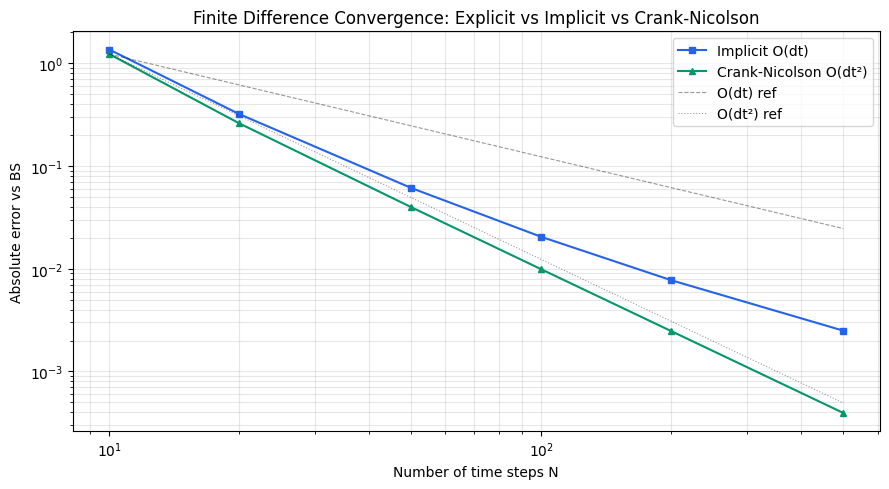

In [9]:
N_vals    = [10, 20, 50, 100, 200, 500]
exp_errs  = []
imp_errs  = []
cn_errs   = []

for N in N_vals:
    try:
        e = fd_explicit(**params, option_type="call", I=300, N=N*5)
        if not np.isfinite(e) or abs(e - bs_c) > 10:
            e = np.nan
    except Exception:
        e = np.nan
    exp_errs.append(abs(e - bs_c) if np.isfinite(e) else np.nan)
    imp_errs.append(abs(fd_implicit(**params, option_type="call", I=N*2, N=N) - bs_c))
    cn_errs.append( abs(fd_crank_nicolson(**params, option_type="call", I=N*2, N=N) - bs_c))

fig, ax = plt.subplots(figsize=(9, 5))
valid_exp = [(N, e) for N, e in zip(N_vals, exp_errs) if np.isfinite(e)]
if valid_exp:
    Nv, ev = zip(*valid_exp)
    ax.loglog(Nv, ev, "o--", color="#DC2626", lw=1.5, ms=5, label="Explicit O(dt)")
ax.loglog(N_vals, imp_errs, "s-",  color="#2563EB", lw=1.5, ms=5, label="Implicit O(dt)")
ax.loglog(N_vals, cn_errs,  "^-",  color="#059669", lw=1.5, ms=5, label="Crank-Nicolson O(dt²)")

# Reference lines
ref_dt  = [cn_errs[0] * (N_vals[0] / N)    for N in N_vals]
ref_dt2 = [cn_errs[0] * (N_vals[0] / N)**2 for N in N_vals]
ax.loglog(N_vals, ref_dt,  "k--", lw=0.8, alpha=0.4, label="O(dt) ref")
ax.loglog(N_vals, ref_dt2, "k:",  lw=0.8, alpha=0.4, label="O(dt²) ref")

ax.set_xlabel("Number of time steps N")
ax.set_ylabel("Absolute error vs BS")
ax.set_title("Finite Difference Convergence: Explicit vs Implicit vs Crank-Nicolson")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("../outputs/fd_convergence.png", dpi=150, bbox_inches="tight")
plt.show()


American put (S=K=100): 6.0773


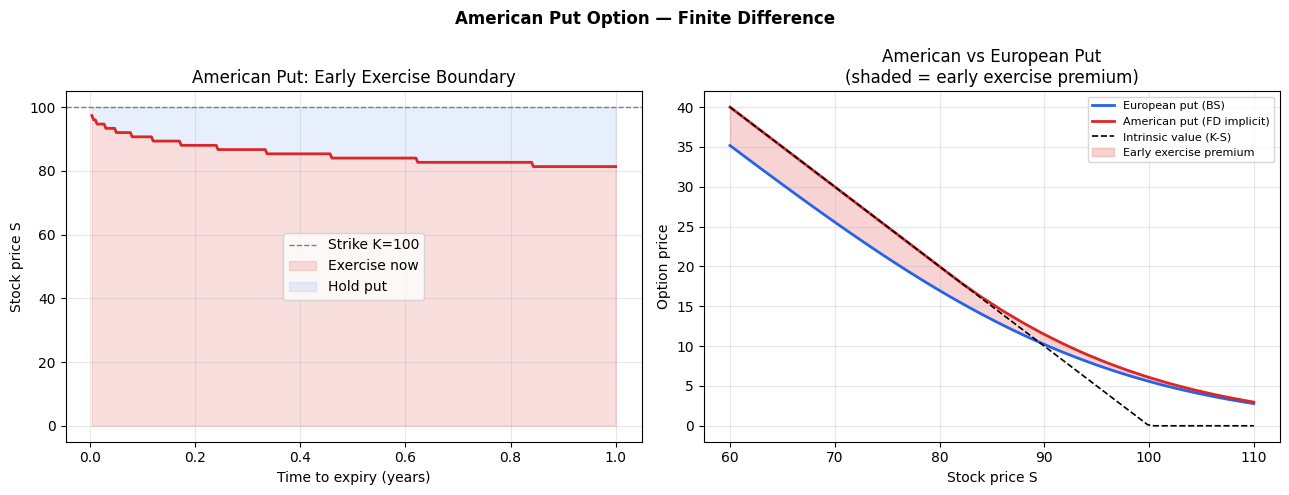

In [12]:
def fd_american_put_with_boundary(K, T, r, sigma, q=0.0, I=300, N=300):
    """
    Price American put and extract early exercise boundary at each time step.
    Returns: (price at S=K, boundary array, time array)
    """
    S_max = 4 * K
    dS    = S_max / I
    dt    = T / N
    S_vec = np.arange(0, I + 1) * dS
    i_arr = np.arange(1, I, dtype=float)

    V = np.maximum(K - S_vec, 0.0)

    sig2i2 = sigma**2 * i_arr**2
    a_vec  = -0.5 * dt * (sig2i2 - (r - q) * i_arr)
    b_vec  =  1.0 + dt * (sig2i2 + r)
    c_vec  = -0.5 * dt * (sig2i2 + (r - q) * i_arr)

    n_int = I - 1
    ab    = np.zeros((3, n_int))
    ab[0, 1:]  = c_vec[:-1]
    ab[1, :]   = b_vec
    ab[2, :-1] = a_vec[1:]

    boundaries = []
    times      = []

    for n in range(N - 1, -1, -1):
        tau = (N - n) * dt
        bc_lo = K * np.exp(-r * tau)
        bc_hi = 0.0

        rhs = V[1:I].copy()
        rhs[0]  -= a_vec[0]  * bc_lo
        rhs[-1] -= c_vec[-1] * bc_hi

        V_int = solve_banded((1, 1), ab, rhs)
        V = np.concatenate([[bc_lo], V_int, [bc_hi]])
        intrinsic = np.maximum(K - S_vec, 0)
        V = np.maximum(V, intrinsic)

        # Extract boundary: highest S where American put = intrinsic value
        # i.e. where it's optimal to exercise immediately.
        # We look for the highest index where V ≤ intrinsic + small tolerance,
        # but only in the ITM region (S < K) to avoid false positives.
        itm_mask  = S_vec < K
        diff      = V - intrinsic
        ex_mask   = (diff < 0.005) & itm_mask
        if ex_mask.any():
            boundaries.append(S_vec[ex_mask].max())
        else:
            # No early exercise region found — boundary is below grid minimum
            boundaries.append(S_vec[1])
        times.append(tau)

    # Price at spot = K
    idx   = K / dS
    i_low = min(int(idx), I - 1)
    w     = idx - i_low
    price = (1 - w) * V[i_low] + w * V[i_low + 1]

    return price, np.array(boundaries[::-1]), np.array(times[::-1])


price_am, boundary, t_arr = fd_american_put_with_boundary(
    K=100, T=1.0, r=0.05, sigma=0.20)

print(f"\nAmerican put (S=K=100): {price_am:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: early exercise boundary
ax = axes[0]
ax.plot(t_arr, boundary, color="#DC2626", lw=2)
ax.axhline(100, color="gray", ls="--", lw=1, label="Strike K=100")
ax.fill_between(t_arr, boundary, 0, alpha=0.15, color="#DC2626", label="Exercise now")
ax.fill_between(t_arr, boundary, 100, alpha=0.1, color="#2563EB", label="Hold put")
ax.set_xlabel("Time to expiry (years)")
ax.set_ylabel("Stock price S")
ax.set_title("American Put: Early Exercise Boundary")
ax.legend()
ax.grid(alpha=0.3)

# Right: American vs European put price along S grid
S_range = np.linspace(60, 110, 80)
eu_puts  = [bs_price(s, 100, 1.0, 0.05, 0.20, option_type="put") for s in S_range]
am_puts  = [fd_implicit(s, 100, 1.0, 0.05, 0.20, option_type="put",
                        exercise="american", I=200, N=200) for s in S_range]
intrinsic = np.maximum(100 - S_range, 0)

ax = axes[1]
ax.plot(S_range, eu_puts,  color="#2563EB", lw=2,   label="European put (BS)")
ax.plot(S_range, am_puts,  color="#DC2626", lw=2,   label="American put (FD implicit)")
ax.plot(S_range, intrinsic,"k--",           lw=1.2, label="Intrinsic value (K-S)")
ax.fill_between(S_range, eu_puts, am_puts, alpha=0.2, color="#DC2626",
                label="Early exercise premium")
ax.set_xlabel("Stock price S")
ax.set_ylabel("Option price")
ax.set_title("American vs European Put\n(shaded = early exercise premium)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle("American Put Option — Finite Difference", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/american_put_fd.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
print("\n" + "="*60)
print("PHASE 4 VALIDATION SUITE")
print("="*60)

passed = failed = 0

def test(name, condition, detail=""):
    global passed, failed
    if condition:
        print(f"  ✓ {name}")
        passed += 1
    else:
        print(f"  ✗ {name}  {detail}")
        failed += 1

# Phase 3 binomial for cross-check
def binomial_tree(S, K, T, r, sigma, q=0.0, N=500,
                  option_type="call", exercise="european"):
    dt = T / N
    u  = np.exp(sigma * np.sqrt(dt))
    d  = 1.0 / u
    p  = (np.exp((r - q) * dt) - d) / (u - d)
    disc = np.exp(-r * dt)
    j  = np.arange(N + 1)
    S_T = S * u**(2*j - N)
    V   = np.maximum(S_T - K, 0) if option_type=="call" else np.maximum(K - S_T, 0)
    for i in range(N-1, -1, -1):
        V = disc * (p * V[1:] + (1-p) * V[:-1])
        if exercise == "american":
            S_i = S * u**(2*np.arange(i+1) - i)
            ex  = np.maximum(S_i - K, 0) if option_type=="call" else np.maximum(K - S_i, 0)
            V   = np.maximum(V, ex)
    return float(V[0])

print("\n[1] All schemes converge to BS (European call)")
tol = 0.01
# Explicit is intentionally excluded — it requires N~30,000 to be stable,
# which is impractical for a validation sweep. Its instability is already
# demonstrated in the stability table (Cell 6). We only validate it there.
for scheme, fn in [("Implicit", fd_implicit),
                   ("Crank-Nicolson", fd_crank_nicolson)]:
    p = fn(**params, option_type="call", I=300, N=500)
    test(f"{scheme}: |price-BS| < {tol}", abs(p - bs_c) < tol,
         f"diff={abs(p-bs_c):.5f}")

print("\n[2] All schemes for European put")
bs_p = bs_price(**params, option_type="put")
for scheme, fn in [("Implicit", fd_implicit),
                   ("Crank-Nicolson", fd_crank_nicolson)]:
    p = fn(**params, option_type="put", I=300, N=500)
    test(f"{scheme} put: |price-BS| < {tol}", abs(p - bs_p) < tol,
         f"diff={abs(p-bs_p):.5f}")

print("\n[3] American put >= European put (FD)")
for K_t in [90, 100, 110]:
    eu = fd_implicit(100, K_t, 1.0, 0.05, 0.20, option_type="put", exercise="european")
    am = fd_implicit(100, K_t, 1.0, 0.05, 0.20, option_type="put", exercise="american")
    test(f"K={K_t}: Am={am:.4f} >= Eu={eu:.4f}", am >= eu - 1e-6)

print("\n[4] American put consistent with Binomial")
for K_t in [90, 100, 110]:
    am_fd  = fd_implicit(100, K_t, 1.0, 0.05, 0.20, option_type="put",
                         exercise="american", I=300, N=300)
    am_bin = binomial_tree(100, K_t, 1.0, 0.05, 0.20,
                           option_type="put", exercise="american", N=500)
    test(f"K={K_t}: FD={am_fd:.4f} vs Bin={am_bin:.4f}",
         abs(am_fd - am_bin) < 0.05, f"diff={abs(am_fd-am_bin):.4f}")

print("\n[5] American call = European call (no dividends)")
ac = fd_implicit(**params, option_type="call", exercise="american", I=200, N=200)
ec = fd_implicit(**params, option_type="call", exercise="european", I=200, N=200)
test(f"No early exercise premium: diff={abs(ac-ec):.5f}", abs(ac - ec) < 0.005)

print("\n[6] CN more accurate than Implicit at same N")
N_coarse = 50
imp_err  = abs(fd_implicit(**params, option_type="call", I=200, N=N_coarse) - bs_c)
cn_err   = abs(fd_crank_nicolson(**params, option_type="call", I=200, N=N_coarse) - bs_c)
test(f"CN error ({cn_err:.5f}) < Implicit error ({imp_err:.5f})", cn_err < imp_err)

print(f"\n{'='*60}")
print(f"Results: {passed} passed, {failed} failed")
if failed == 0:
    print("All tests passed ✓")
    print("Ready for Phase 5 — Heston + Merton + SABR")
print("="*60)


PHASE 4 VALIDATION SUITE

[1] All schemes converge to BS (European call)
  ✓ Implicit: |price-BS| < 0.01
  ✓ Crank-Nicolson: |price-BS| < 0.01

[2] All schemes for European put
  ✓ Implicit put: |price-BS| < 0.01
  ✓ Crank-Nicolson put: |price-BS| < 0.01

[3] American put >= European put (FD)
  ✓ K=90: Am=2.4647 >= Eu=2.3057
  ✓ K=100: Am=6.0674 >= Eu=5.5590
  ✓ K=110: Am=11.9640 >= Eu=10.6749

[4] American put consistent with Binomial
  ✓ K=90: FD=2.4670 vs Bin=2.4724
  ✓ K=100: FD=6.0773 vs Bin=6.0888
  ✓ K=110: FD=11.9621 vs Bin=11.9744

[5] American call = European call (no dividends)
  ✓ No early exercise premium: diff=0.00000

[6] CN more accurate than Implicit at same N
  ✓ CN error (0.00980) < Implicit error (0.03093)

Results: 12 passed, 0 failed
All tests passed ✓
Ready for Phase 5 — Heston + Merton + SABR
